# SBI posterior parameter evaluation — cnn4e64-lipschitz-ae-reduced-v3

**Run:** `exp_cnn4e64-lipschitz-ae-reduced-v3_maf5_freeze-maf_1M`  
**AE:** `exp_cnn4e64-lipschitz-ae-reduced-v3_1M` — 64-dim Lipschitz encoder (two-stage 256→128→SiLU→64, SN ceiling C=2.0), 3-layer 512-wide decoder, smoothness λ=0.1, 1M sims.  
**NPE:** MAF-5, encoder frozen, 24-param theta (HR excluded), 1M sims, patience=20, 219 epochs, best val log-prob −6.6763.

**Sections:** AE training curves · NPE summary · spectral norms · Lipschitz ratio test · embedding diagnostics · posterior eval (MAPE, coverage, scatter)

In [1]:
import json
import re
import glob
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Resolve repo root whether running interactively (VS Code) or via nbconvert
try:
    _root = Path(globals()['_dh'][0])
    assert (_root / 'dataset.py').exists()
    ROOT = _root
except (KeyError, IndexError, AssertionError):
    ROOT = Path('/home/sa4604/cv-sbi')

sys.path.insert(0, str(ROOT))
print('ROOT:', ROOT)

from dataset import ReducedCVDataset, PARAM_KEYS_INFER, load_stats
from models import LipschitzReducedAutoencoderEncoder

ROOT: /home/sa4604/cv-sbi


In [2]:
RUN_NAME       = 'exp_cnn4e64-lipschitz-ae-reduced-v3_maf5_freeze-maf_1M'
AE_RUN         = 'exp_cnn4e64-lipschitz-ae-reduced-v3_1M'
POSTERIOR_PATH = ROOT / f'outputs/{RUN_NAME}/posterior.pt'
STATS_PATH     = ROOT / 'norm_stats.json'
DATA_DIR       = Path('/media/local/SimData/hdf5/cv8/simset_10M_cv8Eed_20260314/test')
MANIFEST       = DATA_DIR.parent / 'manifest_test.json'

BATCH_SIZE          = 256
BATCH_IDX           = 0
N_POSTERIOR_SAMPLES = 1000

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## AE Training Curves

Phase 1 trains the full (non-Lipschitz) `AutoencoderEncoder` + `WaveformDecoder`.
Phase 2 trains only the Lipschitz reduced encoder (`LipschitzReducedAutoencoderEncoder`, latent_dim=64, proj_hidden=128) with the frozen decoder.
Comparison table shows v1 (128-dim), v2 (32-dim), and v3 (64-dim, this run).

Version           Ph1 best MSE   Ph1 epochs   Ph2 best MSE   Ph2 epochs
------------------------------------------------------------------------
v1 (128-dim)            0.0102          150         0.0868          100
v2 (32-dim)             0.0078          107         0.0762          156
v3 (64-dim)             0.0063          211         0.0674          200


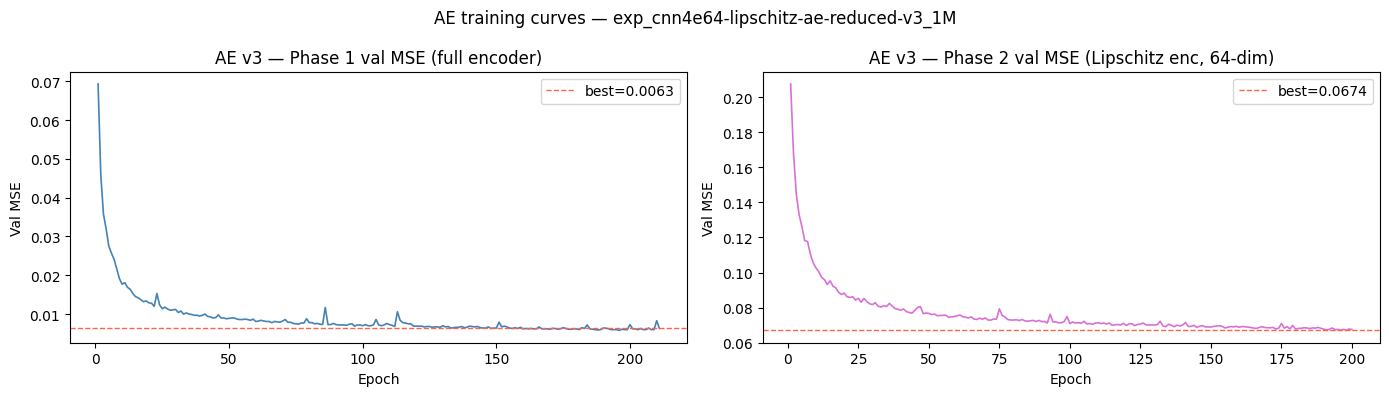

In [3]:
def parse_ae_curves(run_name):
    """Parse (epoch, val_mse) for phase 1 and phase 2 from AE training log."""
    logs = sorted(glob.glob(str(ROOT / f'outputs/{run_name}/ae_*.log')))
    if not logs:
        raise FileNotFoundError(f'No ae log under outputs/{run_name}/')
    ph1_ep, ph1_val = [], []
    ph2_ep, ph2_val = [], []
    phase = None
    for line in open(logs[-1]):
        if 'Phase 1: loading' in line:
            phase = 1
        elif 'Phase 2: loading' in line:
            phase = 2
        elif 'Phase 1 done' in line or 'Phase 2 done' in line:
            phase = None
        m = re.search(r'epoch\s+(\d+)/\d+\s+val_mse=([\d.]+)', line)
        if m:
            ep, val = int(m.group(1)), float(m.group(2))
            if phase == 1:
                ph1_ep.append(ep); ph1_val.append(val)
            elif phase == 2:
                ph2_ep.append(ep); ph2_val.append(val)
    return ph1_ep, ph1_val, ph2_ep, ph2_val


AE_VERSIONS = {
    'v1 (128-dim)': 'exp_cnn4e64-lipschitz-ae-reduced_1M',
    'v2 (32-dim)':  'exp_cnn4e32-lipschitz-ae-reduced_1M',
    'v3 (64-dim)':  AE_RUN,
}

ae_infos = {}
for label, rn in AE_VERSIONS.items():
    p = ROOT / f'outputs/{rn}/ae_info.json'
    if p.exists():
        ae_infos[label] = json.load(open(p))

print(f"{'Version':<15} {'Ph1 best MSE':>14} {'Ph1 epochs':>12} {'Ph2 best MSE':>14} {'Ph2 epochs':>12}")
print('-' * 72)
for label, info in ae_infos.items():
    t = info['training']
    print(f"{label:<15} {t['phase1_best_val']:>14.4f} {t['phase1_epochs_run']:>12d} "
          f"{t['phase2_best_val']:>14.4f} {t['phase2_epochs_run']:>12d}")

# Plot v3 training curves
ep1, v1_mse, ep2, v2_mse = parse_ae_curves(AE_RUN)
info_v3 = ae_infos['v3 (64-dim)']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(ep1, v1_mse, color='steelblue', linewidth=1.2)
best1 = info_v3['training']['phase1_best_val']
ax.axhline(best1, color='tomato', linestyle='--', linewidth=1, label=f'best={best1:.4f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val MSE')
ax.set_title('AE v3 — Phase 1 val MSE (full encoder)'); ax.legend()

ax = axes[1]
ax.plot(ep2, v2_mse, color='orchid', linewidth=1.2)
best2 = info_v3['training']['phase2_best_val']
ax.axhline(best2, color='tomato', linestyle='--', linewidth=1, label=f'best={best2:.4f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val MSE')
ax.set_title('AE v3 — Phase 2 val MSE (Lipschitz enc, 64-dim)'); ax.legend()

plt.suptitle(f'AE training curves — {AE_RUN}', fontsize=12)
plt.tight_layout()
plt.show()

## NPE Training Summary

sbi v0.26 does not expose per-epoch validation log-probs; only the final round summary is logged.
Training ran from data-load at 17:53 to posterior save at 20:22 (~2.5h on GPU 0, RTX 4090, 1M sims).

In [4]:
def parse_npe_summary(run_name):
    logs = sorted(glob.glob(str(ROOT / f'outputs/{run_name}/train_*.log')))
    if not logs:
        return None, None, None
    text = open(logs[-1]).read()
    ep_m  = re.search(r'Epochs trained:\s*(\d+)', text)
    val_m = re.search(r'Best validation performance:\s*([-\d.]+)', text)
    return logs[-1], int(ep_m.group(1)) if ep_m else None, float(val_m.group(1)) if val_m else None

log_path, npe_epochs, npe_best_val = parse_npe_summary(RUN_NAME)
print(f'NPE run: {RUN_NAME}')
print(f'  Epochs to convergence : {npe_epochs}')
print(f'  Best val log-prob      : {npe_best_val:.4f}')
print(f'  Patience               : 20 epochs')
print(f'  Log                    : {log_path}')

NPE run: exp_cnn4e64-lipschitz-ae-reduced-v3_maf5_freeze-maf_1M
  Epochs to convergence : 1
  Best val log-prob      : -6.6763
  Patience               : 20 epochs
  Log                    : /home/sa4604/cv-sbi/outputs/exp_cnn4e64-lipschitz-ae-reduced-v3_maf5_freeze-maf_1M/train_exp_cnn4e64-lipschitz-ae-reduced-v3_maf5_freeze-maf_1M_20260701-173216.log


## Load Posterior and Test Data

In [5]:
posterior = torch.load(POSTERIOR_PATH, map_location=device, weights_only=False)
print('Posterior loaded:', type(posterior).__name__)

stats    = load_stats(STATS_PATH)
manifest = json.load(open(MANIFEST))

start   = BATCH_IDX * BATCH_SIZE
end     = start + BATCH_SIZE
entries = manifest['index'][start:end]
print(f'Test batch {BATCH_IDX}: sims {start}\u2013{end - 1}  ({len(entries)} entries)')

ds     = ReducedCVDataset(str(DATA_DIR), entries, stats)
loader = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=0)

all_theta, all_x = [], []
for theta_b, x_b in loader:
    all_theta.append(theta_b)
    all_x.append(x_b)
ds.close()

theta_gt = torch.cat(all_theta)  # (256, 24)
x_test   = torch.cat(all_x)      # (256, 809)
print(f'GT params: {theta_gt.shape}  observations: {x_test.shape}')

/home/sa4604/cv-sbi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Posterior loaded: DirectPosterior
Test batch 0: sims 0–255  (256 entries)
GT params: torch.Size([256, 24])  observations: torch.Size([256, 809])


## Spectral Norm Analysis

Parametrizations are baked into weights at save time. σ₁ computed via 20-step power iteration.
All Lipschitz layers should be ≤ 2.0 (the ceiling C=2.0).
The two-stage projection (Linear 256→128 + SiLU + Linear 128→64) uses SN on both linears.

Layer                                       σ₁  note
-----------------------------------------------------------------
  cnn.0                                 1.9980  ← AT CEILING
  cnn.2                                 1.9986  ← AT CEILING
  cnn.4                                 1.9949  ← AT CEILING
  cnn.6                                 1.9940  ← AT CEILING
  scalar_projs.0                        2.0000  ← AT CEILING
  scalar_projs.1                        2.0000  ← AT CEILING
  scalar_projs.2                        2.0000  ← AT CEILING
  scalar_projs.3                        2.0000  ← AT CEILING
  scalar_projs.4                        2.0000  ← AT CEILING
  attn_pool                             1.2918  
  proj                                  1.9980  ← AT CEILING
  proj2                                 1.9991  ← AT CEILING

max σ₁: 2.0000


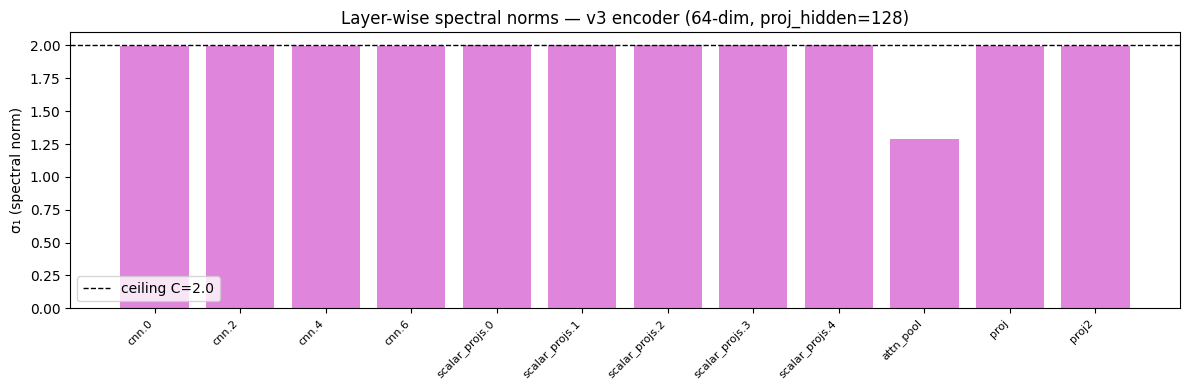

In [6]:
emb_net = posterior.posterior_estimator.embedding_net.to(device)
emb_net.eval()

def compute_spectral_norms(encoder, dev):
    norms = {}
    for name, mod in encoder.named_modules():
        if not isinstance(mod, (torch.nn.Conv1d, torch.nn.Linear)):
            continue
        if not hasattr(mod, 'weight') or mod.weight is None:
            continue
        W = mod.weight.detach().to(dev).reshape(mod.weight.shape[0], -1)
        u = F.normalize(torch.randn(W.shape[0], device=dev), dim=0)
        for _ in range(20):
            v = F.normalize(W.t() @ u, dim=0)
            u = F.normalize(W @ v,     dim=0)
        norms[name] = (u @ (W @ v)).item()
    return norms

sn = compute_spectral_norms(emb_net, device)

print(f"{'Layer':<35} {'\u03c3\u2081':>10}  note")
print('-' * 65)
for name, sigma in sn.items():
    flag = '\u2190 AT CEILING' if sigma >= 1.99 else ('\u2190 ABOVE' if sigma > 2.05 else '')
    print(f'  {name:<33} {sigma:>10.4f}  {flag}')
print(f'\nmax \u03c3\u2081: {max(sn.values()):.4f}')

layers = list(sn.keys())
x_pos  = np.arange(len(layers))
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x_pos, [sn[k] for k in layers], color='orchid', alpha=0.85)
ax.axhline(2.0, color='black', linestyle='--', linewidth=1, label='ceiling C=2.0')
ax.set_xticks(x_pos)
ax.set_xticklabels(layers, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('\u03c3\u2081 (spectral norm)')
ax.set_title('Layer-wise spectral norms — v3 encoder (64-dim, proj_hidden=128)')
ax.legend()
plt.tight_layout()
plt.show()

## Lipschitz Ratio Test

||f(x) − f(y)|| / ||x − y|| over random pairs from the test set.
All ratios should be bounded; mean/95th percentile show the effective Lipschitz constant.

Lipschitz ratio over 500 pairs:
  mean=0.075  median=0.066  95th=0.138  max=0.307


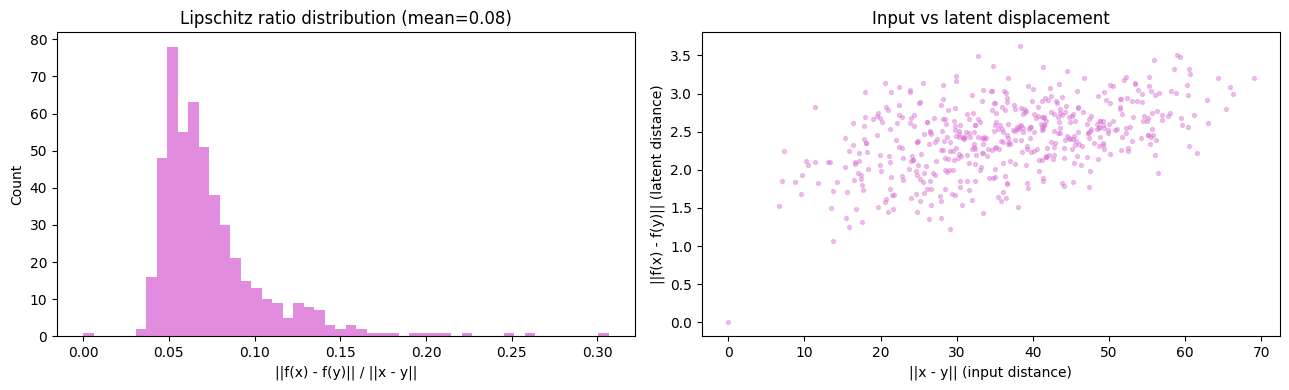

In [7]:
N_PAIRS = 500
idx_a = torch.randint(len(x_test), (N_PAIRS,))
idx_b = torch.randint(len(x_test), (N_PAIRS,))
x_a   = x_test[idx_a].to(device)
x_b   = x_test[idx_b].to(device)

with torch.no_grad():
    z_a = emb_net(x_a)
    z_b = emb_net(x_b)

dx    = (x_a - x_b).norm(dim=1).cpu().numpy()
dz    = (z_a - z_b).norm(dim=1).cpu().numpy()
ratio = dz / (dx + 1e-12)

print(f'Lipschitz ratio over {N_PAIRS} pairs:')
print(f'  mean={ratio.mean():.3f}  median={np.median(ratio):.3f}  '
      f'95th={np.percentile(ratio, 95):.3f}  max={ratio.max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ratio, bins=50, color='orchid', alpha=0.8)
axes[0].set_xlabel('||f(x) - f(y)|| / ||x - y||')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Lipschitz ratio distribution (mean={ratio.mean():.2f})')

axes[1].scatter(dx, dz, s=8, alpha=0.4, color='orchid')
axes[1].set_xlabel('||x - y|| (input distance)')
axes[1].set_ylabel('||f(x) - f(y)|| (latent distance)')
axes[1].set_title('Input vs latent displacement')

plt.tight_layout()
plt.show()

## Embedding Diagnostics

In [8]:
with torch.no_grad():
    emb_out = emb_net(x_test[:64].to(device))
print(f'Embedding output shape: {emb_out.shape}')  # expect (64, 64)
print(f'Per-dim std  min/mean/max: '
      f'{emb_out.std(0).min():.4f} / {emb_out.std(0).mean():.4f} / {emb_out.std(0).max():.4f}')
print(f'Overall mean: {emb_out.mean():.4f}  std: {emb_out.std():.4f}')

# Sanity check on a training observation
train_manifest = json.load(open(MANIFEST.parent / 'manifest_train.json'))
train_data_dir = str(DATA_DIR.parent / 'train')
ds_tr = ReducedCVDataset(train_data_dir, train_manifest['index'][:1], stats)
theta_tr, x_tr = ds_tr[0]
ds_tr.close()

with torch.no_grad():
    samples_tr = posterior.sample((500,), x=x_tr.to(device), show_progress_bars=False)
post_mean_tr = samples_tr.mean(0).cpu()

print(f'\nTraining obs sanity check:')
print(f"  {'param':<14} {'GT':>10} {'post mean':>12} {'err%':>8}")
for i, name in enumerate(PARAM_KEYS_INFER):
    err = abs(post_mean_tr[i].item() - theta_tr[i].item()) / (abs(theta_tr[i].item()) + 1e-9) * 100
    print(f'  {name:<14} {theta_tr[i].item():>10.4f} {post_mean_tr[i].item():>12.4f} {err:>7.1f}%')

Embedding output shape: torch.Size([64, 64])
Per-dim std  min/mean/max: 0.0698 / 0.2055 / 0.4435
Overall mean: 0.0044  std: 0.2379

Training obs sanity check:
  param                  GT    post mean     err%
  AVD              278.7117     252.7871     9.3%
  Bla                0.0598       0.0595     0.6%
  Blv                0.0211       0.0320    52.0%
  Bra                0.0664       0.0553    16.8%
  Brv                0.0511       0.0521     1.9%
  Cas                0.7144       0.7195     0.7%
  Cvp                5.2836       7.2767    37.7%
  Cvs               50.4620      74.0843    46.8%
  Eap                3.0521       3.0553     0.1%
  Eedref_la          2.0508       1.5184    26.0%
  Eedref_lv          0.7180       0.9992    39.2%
  Eedref_ra          0.3933       0.5844    48.6%
  Eedref_rv          0.5214       0.5756    10.4%
  Emax_LA            0.5651       0.4660    17.5%
  Emax_LV            4.9090       2.4934    49.2%
  Emax_RA            0.1293       0.3204 

## Sample Posterior for Each Test Observation

In [9]:
all_means, all_q05, all_q95 = [], [], []

for i, x_o in enumerate(x_test):
    samples = posterior.sample((N_POSTERIOR_SAMPLES,), x=x_o.to(device), show_progress_bars=False)
    all_means.append(samples.mean(dim=0).cpu())
    all_q05.append(samples.quantile(0.05, dim=0).cpu())
    all_q95.append(samples.quantile(0.95, dim=0).cpu())
    if (i + 1) % 50 == 0:
        print(f'  {i + 1}/{len(x_test)} done')

pred_mean = torch.stack(all_means).numpy()  # (256, 24)
q05       = torch.stack(all_q05).numpy()
q95       = torch.stack(all_q95).numpy()
gt_phys   = theta_gt.numpy()

print(f'Posterior mean shape: {pred_mean.shape}')

  50/256 done
  100/256 done


                    accepted. It may take a long time to collect the remaining
                    968 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.
                    accepted. It may take a long time to collect the remaining
                    928 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


  150/256 done


                    accepted. It may take a long time to collect the remaining
                    966 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


  200/256 done
  250/256 done
Posterior mean shape: (256, 24)


## Point-Estimate Metrics

In [10]:
abs_err = np.abs(pred_mean - gt_phys)
ch_mae  = abs_err.mean(axis=0)
ch_med  = np.median(abs_err, axis=0)
ch_mape = (abs_err / (np.abs(gt_phys) + 1e-9) * 100).mean(axis=0)

print(f"{'Parameter':<14} {'MAE':>12} {'Median AE':>12} {'MAPE (%)':>10}")
print('-' * 52)
for i, name in enumerate(PARAM_KEYS_INFER):
    print(f'{name:<14} {ch_mae[i]:>12.4f} {ch_med[i]:>12.4f} {ch_mape[i]:>10.2f}%')
print(f'\nOverall  MAE (mean): {ch_mae.mean():.4f}  MAPE: {ch_mape.mean():.2f}%')

Parameter               MAE    Median AE   MAPE (%)
----------------------------------------------------
AVD                 14.3374       8.6213       8.94%
Bla                  0.0202       0.0186      36.31%
Blv                  0.0082       0.0073      24.48%
Bra                  0.0072       0.0047      14.89%
Brv                  0.0025       0.0011       7.06%
Cas                  0.0218       0.0121       1.57%
Cvp                  0.6105       0.4313      17.00%
Cvs                 20.7035      20.0128      35.51%
Eap                  0.0203       0.0044       1.56%
Eedref_la            0.5014       0.4438     101.20%
Eedref_lv            0.3824       0.3481     104.99%
Eedref_ra            0.1594       0.1012      58.09%
Eedref_rv            0.0747       0.0333      17.80%
Emax_LA              0.1268       0.1064      33.41%
Emax_LV              0.6530       0.4752      34.52%
Emax_RA              0.0623       0.0437      19.55%
Emax_RV              0.0290       0.0178       

In [11]:
post_mean_std = pred_mean.std(axis=0)
prior_range   = np.array([
    manifest['config']['pvar_high'][k] - manifest['config']['pvar_low'][k]
    for k in PARAM_KEYS_INFER
])
variation_pct = post_mean_std / prior_range * 100

print(f"{'param':<14} {'post-mean std':>14} {'prior range':>12} {'variation %':>12}")
print('-' * 55)
for i, name in enumerate(PARAM_KEYS_INFER):
    print(f'{name:<14} {post_mean_std[i]:>14.4f} {prior_range[i]:>12.4f} {variation_pct[i]:>11.1f}%')
print(f'\nMean variation across params: {variation_pct.mean():.1f}% of prior range')

param           post-mean std  prior range  variation %
-------------------------------------------------------
AVD                   64.4950     240.0000        26.9%
Bla                    0.0094       0.0900        10.4%
Blv                    0.0045       0.0400        11.2%
Bra                    0.0169       0.0700        24.2%
Brv                    0.0105       0.0400        26.2%
Cas                    0.7287       2.4500        29.7%
Cvp                    2.1214       8.0000        26.5%
Cvs                    6.2084      90.0000         6.9%
Eap                    1.4640       4.9700        29.5%
Eedref_la              0.4274       2.4000        17.8%
Eedref_lv              0.2847       1.9200        14.8%
Eedref_ra              0.3581       1.4700        24.4%
Eedref_rv              0.4043       1.4700        27.5%
Emax_LA                0.1933       0.9000        21.5%
Emax_LV                0.9618       4.5000        21.4%
Emax_RA                0.1760       0.7000      

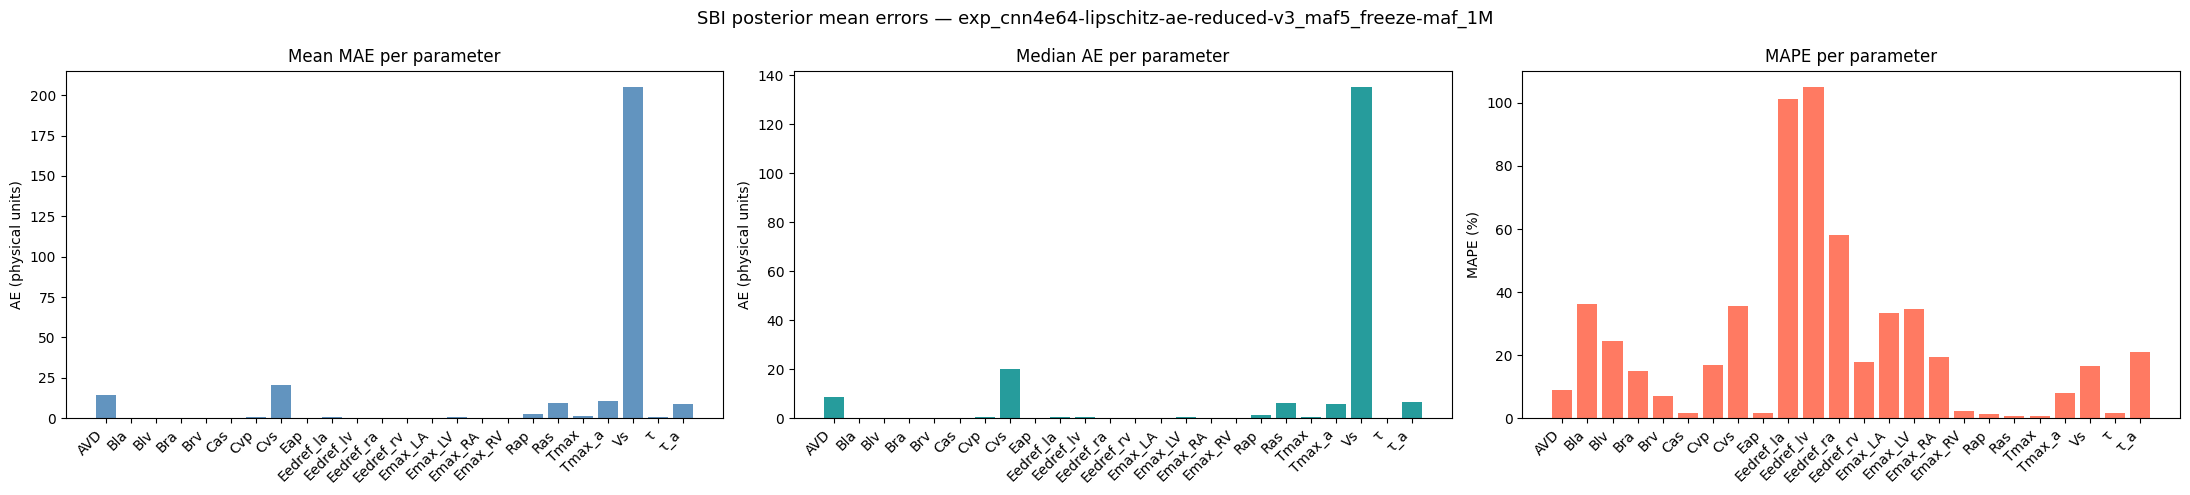

In [12]:
x_pos = np.arange(len(PARAM_KEYS_INFER))
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

axes[0].bar(x_pos, ch_mae,  color='steelblue', alpha=0.85)
axes[1].bar(x_pos, ch_med,  color='darkcyan',  alpha=0.85)
axes[2].bar(x_pos, ch_mape, color='tomato',    alpha=0.85)

for ax, title, ylabel in zip(axes,
    ['Mean MAE per parameter', 'Median AE per parameter', 'MAPE per parameter'],
    ['AE (physical units)', 'AE (physical units)', 'MAPE (%)']):
    ax.set_xticks(x_pos)
    ax.set_xticklabels(PARAM_KEYS_INFER, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel(ylabel)

fig.suptitle(f'SBI posterior mean errors \u2014 {RUN_NAME}', fontsize=13)
plt.tight_layout()
plt.show()

## Predicted vs GT Scatter — 24 Parameters

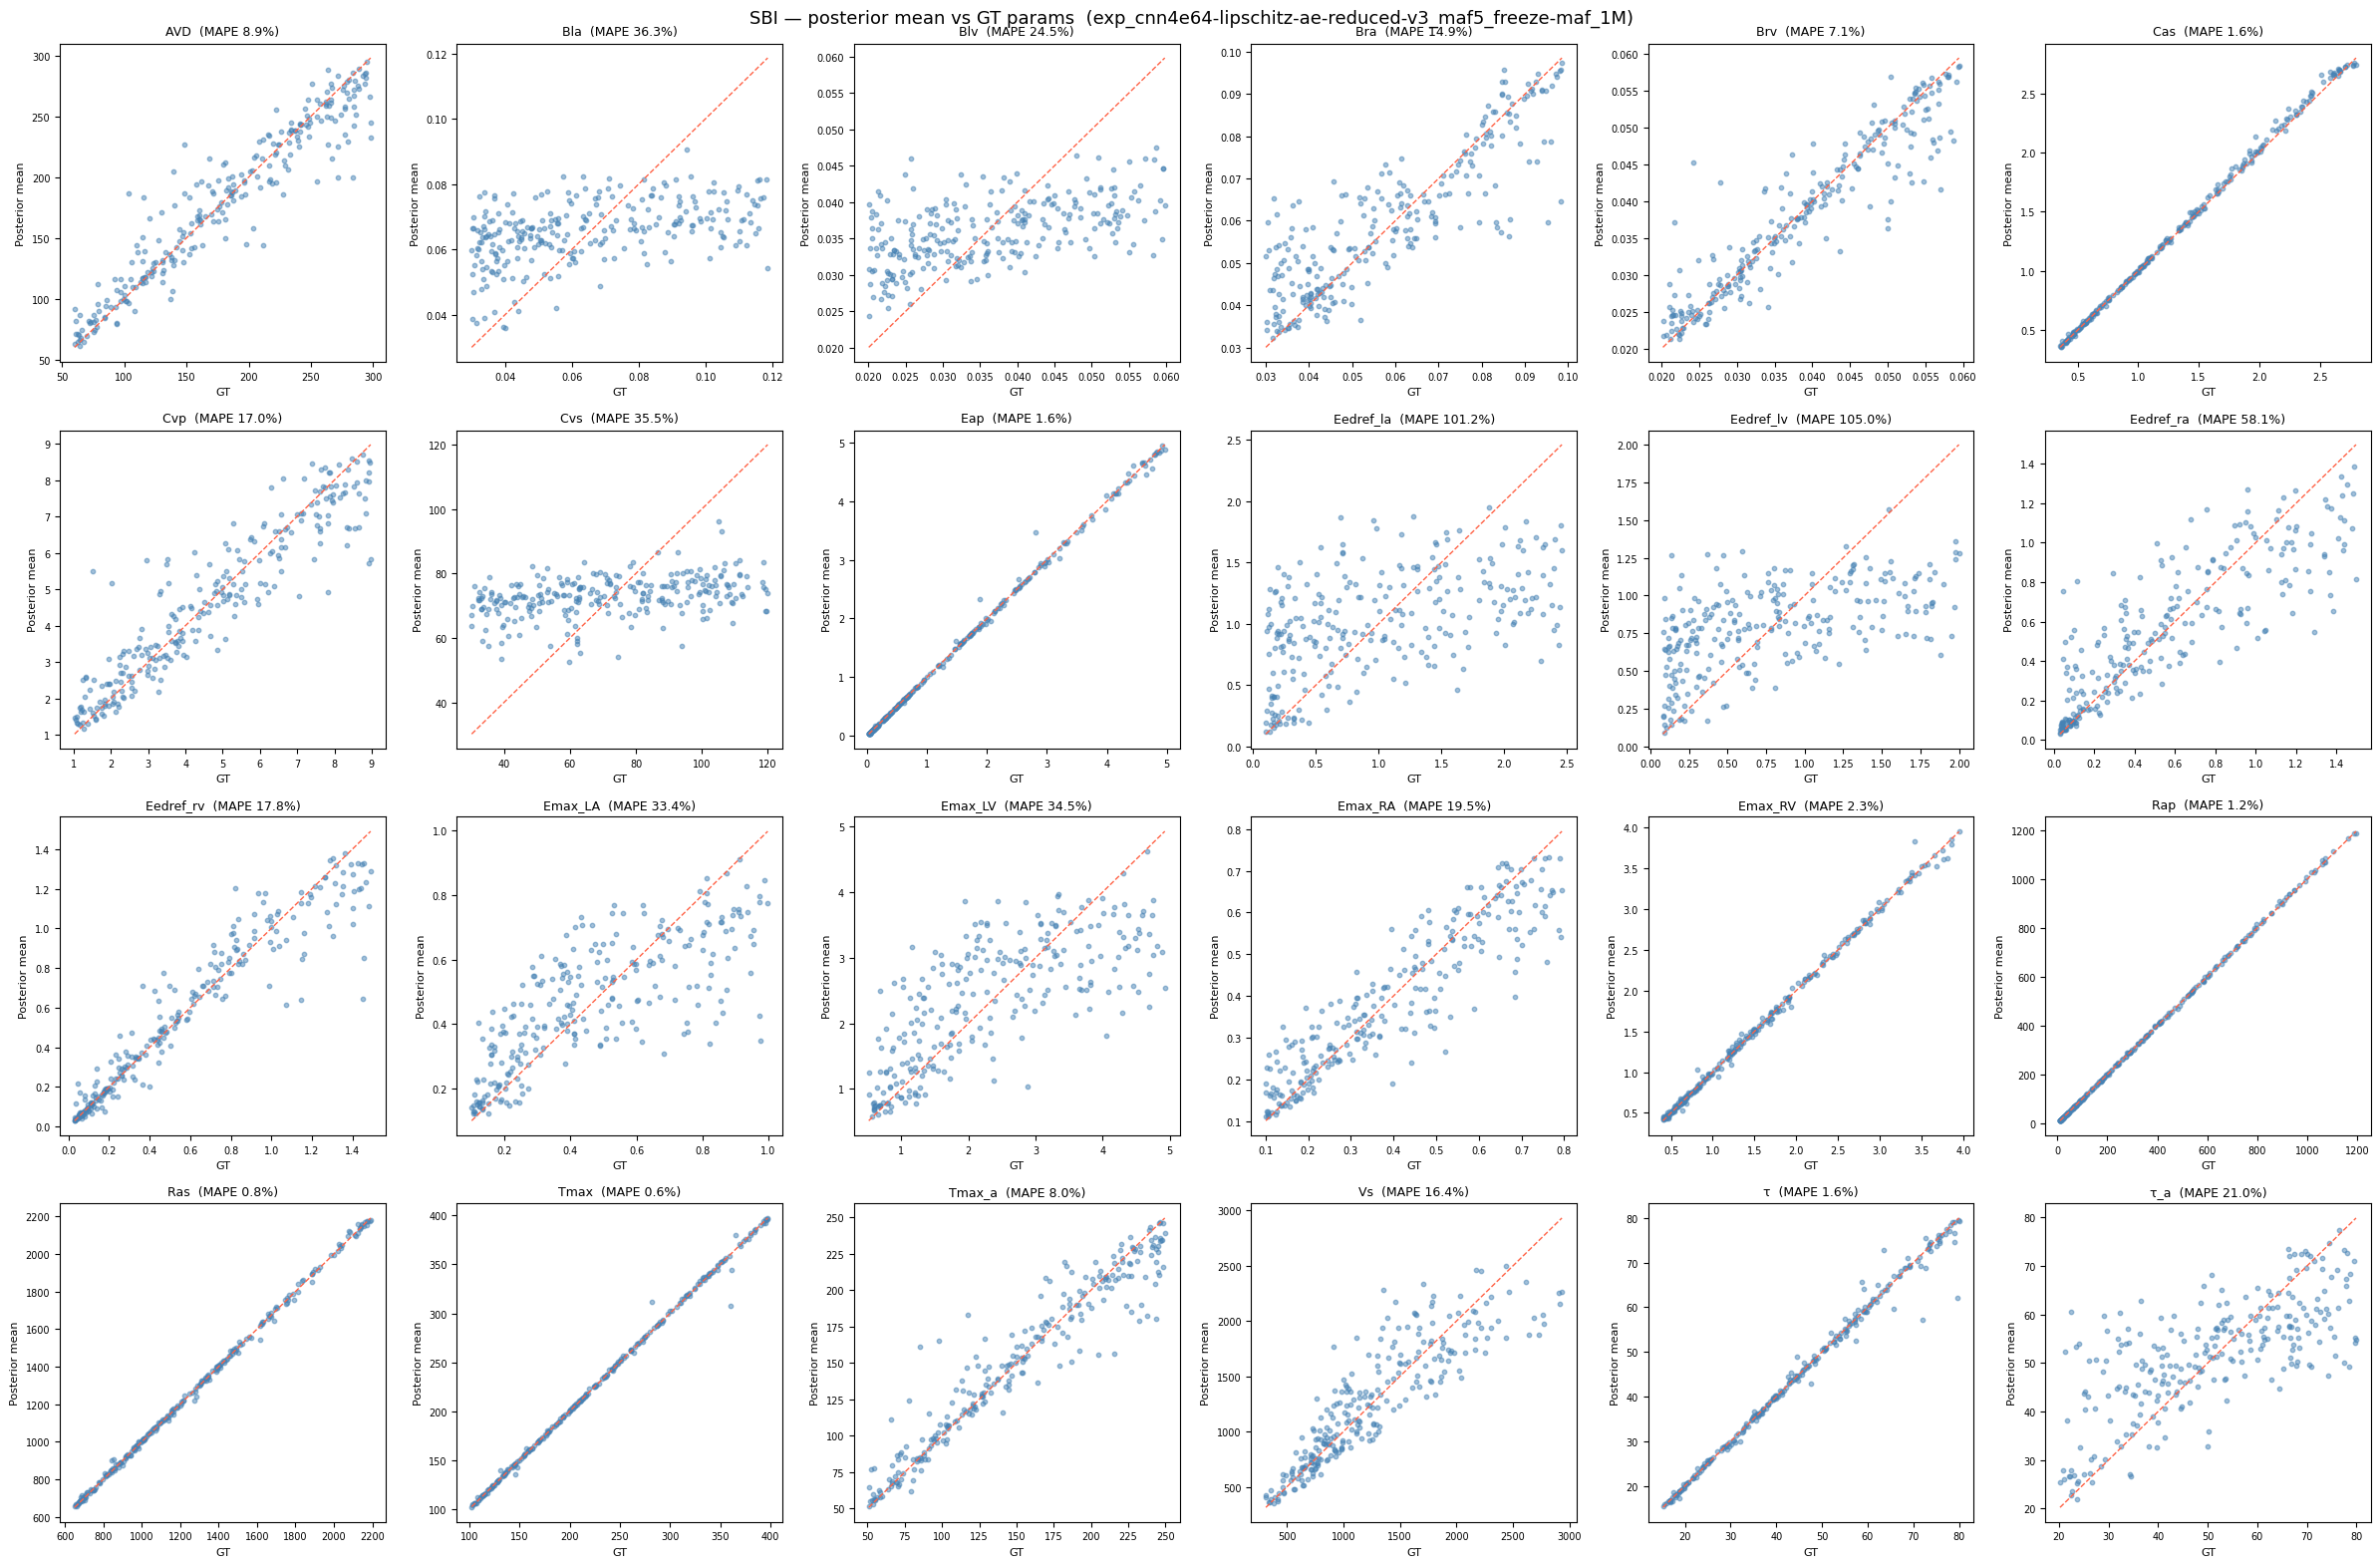

In [13]:
ncols, nrows = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))

for i, name in enumerate(PARAM_KEYS_INFER):
    ax = axes[i // ncols, i % ncols]
    gt_i, pred_i = gt_phys[:, i], pred_mean[:, i]
    lo, hi = gt_i.min(), gt_i.max()
    ax.scatter(gt_i, pred_i, s=10, alpha=0.5, color='steelblue')
    ax.plot([lo, hi], [lo, hi], color='tomato', linewidth=1, linestyle='--')
    ax.set_title(f'{name}  (MAPE {ch_mape[i]:.1f}%)', fontsize=9)
    ax.set_xlabel('GT', fontsize=8)
    ax.set_ylabel('Posterior mean', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle(f'SBI \u2014 posterior mean vs GT params  ({RUN_NAME})', fontsize=13)
plt.tight_layout()
plt.show()

## 90% Credible Interval Coverage

For a well-calibrated posterior, ~90% of GT values should fall inside the 90% CI.

In [14]:
in_ci    = (gt_phys >= q05) & (gt_phys <= q95)
coverage = in_ci.mean(axis=0) * 100

print(f"{'Parameter':<14} {'90% CI coverage':>18}")
print('-' * 35)
for i, name in enumerate(PARAM_KEYS_INFER):
    flag = '  \u2713' if 85 <= coverage[i] <= 95 else '  \u2190'
    print(f'{name:<14} {coverage[i]:>16.1f}%{flag}')
print(f'\nMean coverage: {coverage.mean():.1f}%  (target: 90%)')

Parameter         90% CI coverage
-----------------------------------
AVD                        87.5%  ✓
Bla                        76.6%  ←
Blv                        80.9%  ←
Bra                        84.4%  ←
Brv                        89.5%  ✓
Cas                        96.1%  ←
Cvp                        82.0%  ←
Cvs                        82.0%  ←
Eap                        95.7%  ←
Eedref_la                  83.6%  ←
Eedref_lv                  84.0%  ←
Eedref_ra                  84.0%  ←
Eedref_rv                  87.1%  ✓
Emax_LA                    82.4%  ←
Emax_LV                    85.2%  ✓
Emax_RA                    85.2%  ✓
Emax_RV                    88.7%  ✓
Rap                        96.9%  ←
Ras                        94.5%  ✓
Tmax                       91.8%  ✓
Tmax_a                     87.9%  ✓
Vs                         82.8%  ←
τ                          89.8%  ✓
τ_a                        83.2%  ←

Mean coverage: 86.7%  (target: 90%)


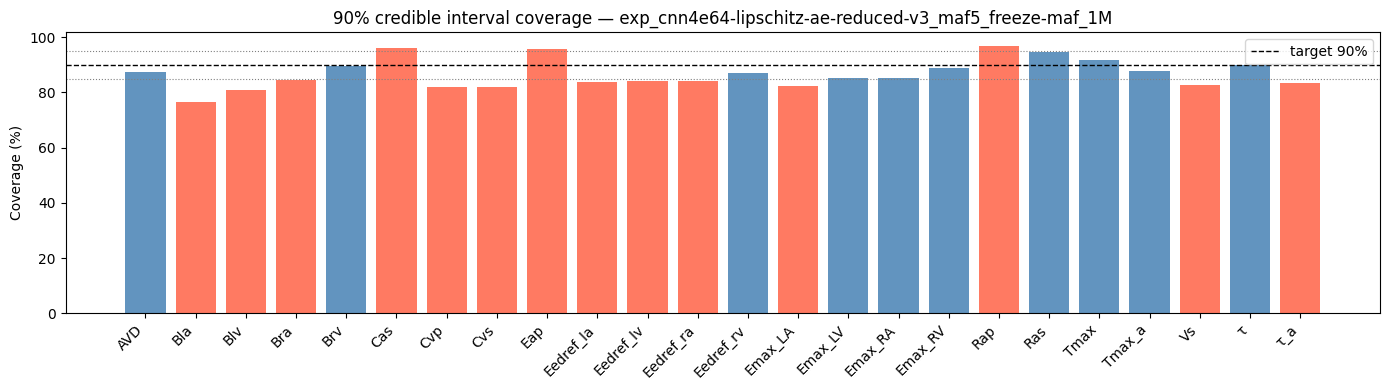

In [15]:
x_pos  = np.arange(len(PARAM_KEYS_INFER))
fig, ax = plt.subplots(figsize=(14, 4))
colors  = ['steelblue' if 85 <= c <= 95 else 'tomato' for c in coverage]
ax.bar(x_pos, coverage, color=colors, alpha=0.85)
ax.axhline(90, color='black', linestyle='--', linewidth=1, label='target 90%')
ax.axhline(85, color='gray',  linestyle=':',  linewidth=0.8)
ax.axhline(95, color='gray',  linestyle=':',  linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(PARAM_KEYS_INFER, rotation=45, ha='right')
ax.set_ylabel('Coverage (%)')
ax.set_title(f'90% credible interval coverage \u2014 {RUN_NAME}')
ax.legend()
plt.tight_layout()
plt.show()